# MAIN NOTEBOOK

Main script to run the DAE system simulation, calibrating and analysis for a given model.

## File editing

In order to run the correct model, you must add a folder with your model name (e.g. "M_smegmatis_O2"). Inside it there must be two `.py` files and an excel file. These must be modified or edited in order to calibrate and analyse your own model. Note that the names of these files should stay the same or the package will not run correctly. The way to discrimitane between model configurations is the use of the previously created folder with your model name.

1) `DAE_System_Simulations.py` : Define your DAE system equations.

2) `System_info.py` : Complete with your system conditions, initial values, etc, as the original file establishes.

2) `Experimental_data.xlsx` : It must be an excel file with your experimental data for parameter calibration and validation. How data is extracted from it should be defined on `System_info.py`.

## Prints and Visualizations

If you want to visualize the optimization prints, go to `RUN_functions.py` and follow the instructions on line 20.

If you want to visualize the workflow prints of the calibrations comment the following line on your cell:
```python
    builtins.print = lambda *args, **kwargs: None # Disable all print statements
```

## Parameter Calibration and Analysis

In [ ]:
from DAE_analysis_package.RUN_functions import RUN_ALL_COMBOS       # Main function to run all combinations of parameter sets and bounds
from M_smegmatis_O2.DAE_Systems_Simulations import simulate_model   # Function to simulate the DAE system
from M_smegmatis_O2.System_data import system_data                  # System data including initial conditions, parameters, and experimental data

# To disable all print statements, uncomment the following two lines
import builtins
builtins.print = lambda *args, **kwargs: None 

# Define the parameters to calibrate and their bounds. 
    # Useful tip: write the dictionary with all parameters and bounds, then comment 
    # the ones you don't want to calibrate, for easier future modifications.

parameters_and_bounds = {
    # 'k_C': [0.01,0.1], 
    # 'k_N': [0.0105,0.5], 
    # 'k_O' : [0.0001,0.009], 
    # 'k_d': [0.001,0.005], 
    # 'YX_CO2': [0.1,1.0], 
    # 'YX_O2' : [0.5,5], 
    # 'YX_C': [0.35,0.8],
    'YX_N': [10.4, 10.6],         
    'Xmax': [1.15, 1.17],  
    # 'mu_max': [0.13, 0.15],  
    # 'pH_LL': [1,4.8],
    # 'pH_UL': [5.5, 21], 
    # 'I_val': [1,5], 
    # 't_lag': [6,10]
    } 

updated_parameters = {
    'k_C': 50, 
    'k_N': 56566565, 
    'k_O' : 0.005}

# Run all combinations of parameter sets and bounds for model calibration
df_M_smegmatis_O2 = RUN_ALL_COMBOS(
                    system_data=system_data,                        # Model system data
                    simulate_model=simulate_model,                  # Function to simulate your DAE system
                    iterations=30,                                   # Number of iterations for each parameter combination
                    parameters_and_bounds=parameters_and_bounds,    # Parameters to calibrate and their bounds
                    folder_model='M_smegmatis_O2',                  # Name of the DAE System
                    folder_calibration_results='Calibration_3',     # Name of the current calibration run
                    updated_parameters=updated_parameters,          # Parameters to update before calibration (if any)
                    # min_k = 1,                                    # Minimum number of parameters to calibrate simultaneously (optional)
                    # max_k = 3,                                    # Maximum number of parameters to calibrate simultaneously (optional
                )

CasADi - 2025-10-01 22:11:00 WARNING("The options 't0', 'tf', 'grid' and 'output_t0' have been deprecated.
The same functionality is provided by providing additional input arguments to the 'integrator' function, in particular:
 * Call integrator(..., t0, tf, options) for a single output time, or
 * Call integrator(..., t0, grid, options) for multiple grid points.
The legacy 'output_t0' option can be emulated by including or excluding 't0' in 'grid'.
Backwards compatibility is provided in this release only.") [D:\bld\casadi_1739119754930\work\casadi\core\integrator.cpp:521]
c:\Users\camil\OneDrive\DAE Model Analysis\DAE_System_Model_Calibration_and_Validation\DAE_analysis_package\Plotting_functions.py:121: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.96])


In [11]:
from itertools import combinations


max_k = None
min_k = 1

parameters_and_bounds = {
    'k_C': [0.01,0.1], 
    'k_N': [0.0105,0.5], 
    'k_O' : [0.0001,0.009], 
    'k_d': [0.001,0.005], 
    'YX_CO2': [0.1,1.0], 
    'YX_O2' : [0.5,5], 
    'YX_C': [0.35,0.8],
    'YX_N': [10.4, 10.6],         
    'Xmax': [1.15, 1.17],  
    'mu_max': [0.13, 0.15],  
    'pH_LL': [1,4.8],
    'pH_UL': [5.5, 21], 
    'I_val': [1,5], 
    't_lag': [6,10]
    } 

params = list(parameters_and_bounds.keys())
n = len(params)
if max_k is None:
    max_k = n
combos = []
for k in range(min_k, max_k + 1):
    for combo in combinations(params, k):
        combos.append(list(combo))
combos.reverse()  # Reverse the list to have larger combinations first
print(len(combos))
print(len(combos)*5) # minutes
print(len(combos) // 12)  # hours
print(len(combos) // 288)  # days

16383
81915
1365
56


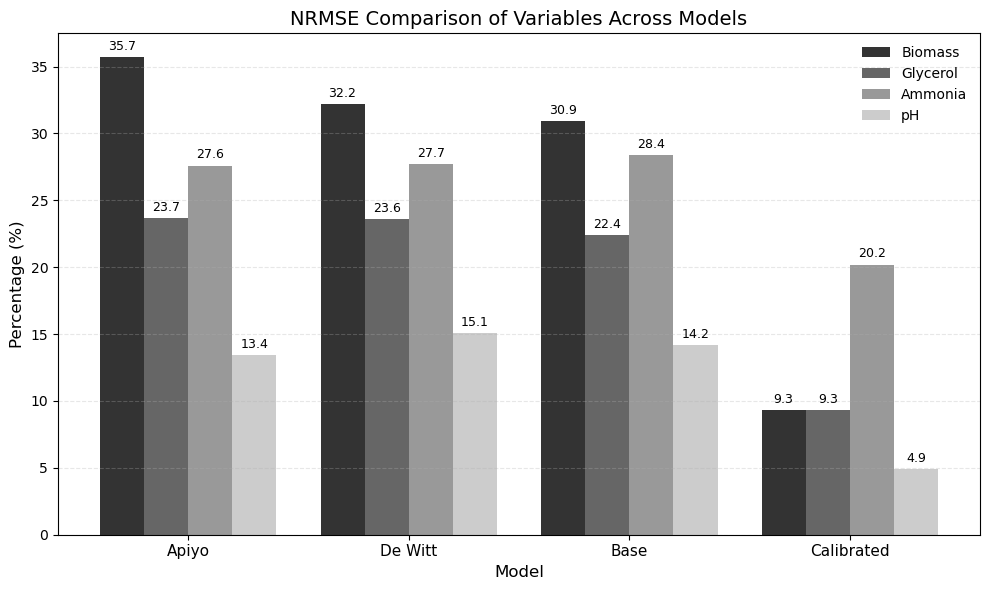

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Data from table
models = ['Apiyo', 'De Witt', 'Base', 'Calibrated']
biomass = [35.7, 32.2, 30.9, 9.29]
glycerol = [23.7, 23.6, 22.4, 9.33]
ammonia = [27.6, 27.7, 28.4, 20.2]
ph = [13.4, 15.1, 14.2, 4.93]

# X-axis positions
x = np.arange(len(models))
width = 0.2  # Bar width

# Define grayscale shades
grays = ['0.2', '0.4', '0.6', '0.8']

# Create plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each variable in different gray tone
ax.bar(x - 1.5*width, biomass, width, color=grays[0], label='Biomass')
ax.bar(x - 0.5*width, glycerol, width, color=grays[1], label='Glycerol')
ax.bar(x + 0.5*width, ammonia, width, color=grays[2], label='Ammonia')
ax.bar(x + 1.5*width, ph, width, color=grays[3], label='pH')

# Labels and title
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_title('NRMSE Comparison of Variables Across Models', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.legend(frameon=False)

# Value labels on top of bars
for bars in ax.containers:
    ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=9, color='black')

# Aesthetic details
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

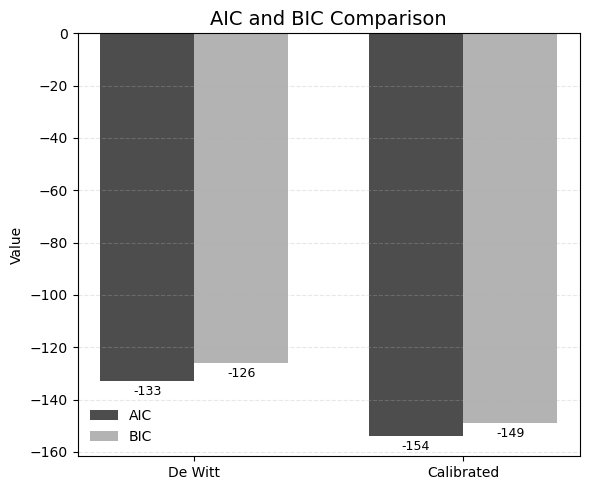

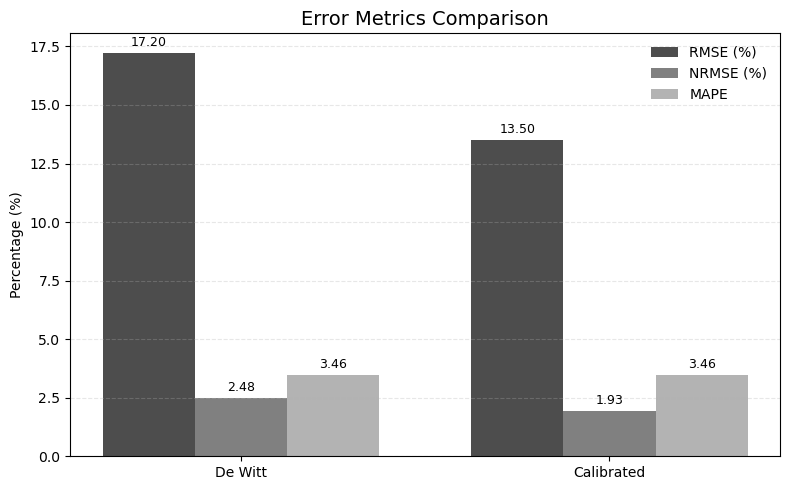

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Models
models = ['De Witt', 'Calibrated']

# Data
AIC   = [-133, -154]
BIC   = [-126, -149]
RMSE  = [17.2, 13.5]
NRMSE = [2.48, 1.93]
MAPE  = [3.46, 3.46]

# -------------------
# FIGURE 1: AIC & BIC
# -------------------

x = np.arange(len(models))
width = 0.35
grays = ['0.3', '0.7']

fig1, ax1 = plt.subplots(figsize=(6, 5))

ax1.bar(x - width/2, AIC, width, color=grays[0], label='AIC')
ax1.bar(x + width/2, BIC, width, color=grays[1], label='BIC')

ax1.set_title('AIC and BIC Comparison', fontsize=14)
ax1.set_ylabel('Value')
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.legend(frameon=False)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Label values
for bars in ax1.containers:
    ax1.bar_label(bars, fmt='%.0f', padding=3, fontsize=9, color='black')

plt.tight_layout()
plt.show()


# --------------------------
# FIGURE 2: RMSE, NRMSE, MAPE
# --------------------------

metrics = ['RMSE (%)', 'NRMSE (%)', 'MAPE']
values = [RMSE, NRMSE, MAPE]

fig2, ax2 = plt.subplots(figsize=(8, 5))

width = 0.25
x = np.arange(len(models))

for i, (metric, vals) in enumerate(zip(metrics, values)):
    ax2.bar(x + (i - 1)*width, vals, width, color=str(0.3 + i*0.2), label=metric)

ax2.set_title('Error Metrics Comparison', fontsize=14)
ax2.set_ylabel('Percentage (%)')
ax2.set_xticks(x)
ax2.set_xticklabels(models)
ax2.legend(frameon=False)
ax2.grid(axis='y', linestyle='--', alpha=0.3)

# Label values
for bars in ax2.containers:
    ax2.bar_label(bars, fmt='%.2f', padding=3, fontsize=9, color='black')

plt.tight_layout()
plt.show()


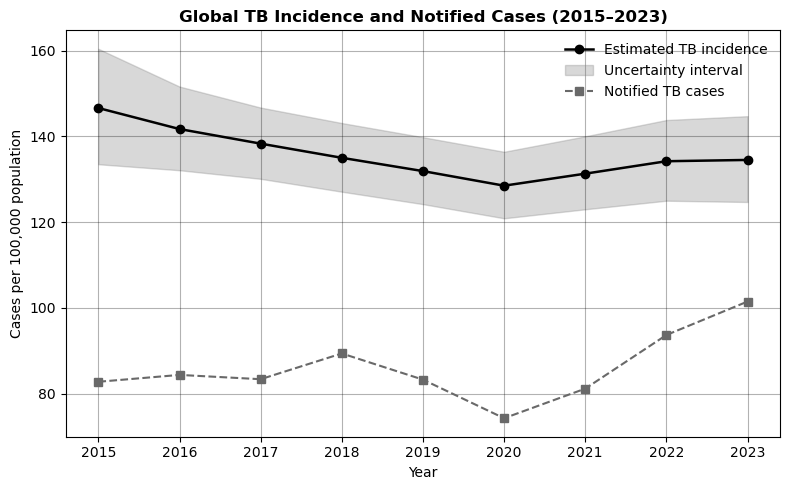

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Data
years = np.array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])
incidence = np.array([146.6, 141.7, 138.3, 135, 131.9, 128.5, 131.3, 134.2, 134.5])
low = np.array([133.5, 132.1, 130.1, 127.1, 124.2, 120.9, 123, 125, 124.7])
high = np.array([160.4, 151.6, 146.7, 143.1, 139.8, 136.4, 140, 143.8, 144.7])
notified = np.array([82.8, 84.4, 83.4, 89.4, 83.3, 74.3, 81.2, 93.7, 101.5])

# Grayscale style
plt.style.use('grayscale')
plt.figure(figsize=(8, 5), facecolor='white')
plt.gca().set_facecolor('white')




# Plot
plt.plot(years, incidence, label="Estimated TB incidence", marker="o", color="black", linewidth=1.8)
plt.fill_between(years, low, high, color="gray", alpha=0.3, label="Uncertainty interval")
plt.plot(years, notified, label="Notified TB cases", marker="s", linestyle="--", color="dimgray", linewidth=1.5)

# Labels and aesthetics
plt.title("Global TB Incidence and Notified Cases (2015–2023)", fontsize=12, weight='bold')
plt.xlabel("Year")
plt.ylabel("Cases per 100,000 population")
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()
